In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm

In [2]:
label_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/Baeklab.070.GP3.depth5_None.twm6astrict.tsv", sep="\t")
label_df = label_df[["id", "depth", "label", "m6A_level", "5mer", "drach"]]
label_df.rename(columns = {"id": "label_id","m6A_level": "dom_label"}, inplace = True)
label_df_filtered = label_df[((label_df["dom_label"] > 0.0) & (label_df["label"] == 1)) | (label_df["label"] == 0)]
print(label_df_filtered["label"].value_counts())

label
0    18399879
1      100118
Name: count, dtype: int64


In [3]:
logsum_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif/pileup.npz"
with np.load(logsum_df, allow_pickle=True) as data:
    logsum_df = pd.DataFrame({key: data[key] for key in data.keys()})
logsum_df = logsum_df[logsum_df["count_dom"] >= 20]
logsum_df = logsum_df.merge(label_df_filtered, on="label_id", how="inner")
print(logsum_df)

                label_id     p_sum  logsum_1_p_pos  count_all  count_dom  \
0         NM_000016:1000  0.606511        0.000000        258        258   
1         NM_000016:1008  0.948786        0.000000        257        256   
2         NM_000016:1009  2.607620        0.000000        260        257   
3         NM_000016:1010  4.912612        0.000000        263        259   
4         NM_000016:1014  3.237954        0.000000        258        252   
...                  ...       ...             ...        ...        ...   
10794116  NR_182669:3964  1.226287        0.000000         54         51   
10794117  NR_182669:3965  1.268912        0.000000         53         51   
10794118  NR_182669:3966  1.295230        0.000000         50         50   
10794119  NR_182669:3968  2.394934       -1.804221         48         48   
10794120  NR_182669:3969  1.723521        0.000000         45         44   

               dom  log_pm6a  depth  label  dom_label   5mer  drach  
0         0.00000

In [4]:
dorado_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/dorado-070-aligned/intermediates/dorado_output.pkl")
print(dorado_df)

                label_id  pred_dorado  dorado_count
0            NM_000015:0          0.5             2
1            NM_000015:5          0.0             2
2            NM_000015:8          0.0             1
3           NM_000015:10          0.0             1
4           NM_000015:12          0.0             1
...                  ...          ...           ...
59479351  NR_184563:7515          0.0             1
59479352  NR_184563:7518          0.0             1
59479353  NR_184563:7525          0.0             2
59479354  NR_184563:7526          0.0             1
59479355  NR_184563:7528          0.0             1

[59479356 rows x 3 columns]


In [5]:
dorado_df = dorado_df[dorado_df["dorado_count"] >= 20]
dorado_df = dorado_df.merge(label_df_filtered, on="label_id", how="inner")
print(dorado_df)

                label_id  pred_dorado  dorado_count  depth  label  dom_label  \
0           NM_000016:21       0.0250           160    168      0        0.0   
1           NM_000016:24       0.0710           155    182      0        0.0   
2           NM_000016:29       0.0460           174    199      0        0.0   
3           NM_000016:30       0.0266           188    200      0        0.0   
4           NM_000016:38       0.0054           185    201      0        0.0   
...                  ...          ...           ...    ...    ...        ...   
10438531  NR_182669:3964       0.0000            47     55      0        0.0   
10438532  NR_182669:3965       0.0000            53     55      0        0.0   
10438533  NR_182669:3966       0.1458            48     55      0        0.0   
10438534  NR_182669:3968       0.0000            50     55      0        0.0   
10438535  NR_182669:3969       0.0204            49     55      0        0.0   

           5mer  drach  
0         GGAG

In [6]:
dorado_df = dorado_df[["pred_dorado", "dorado_count", "label_id"]]

In [11]:
eval_df = logsum_df[['dom', 'log_pm6a', 'label_id', 'count_dom', 'label', 'dom_label', 'drach']]
eval_df = eval_df.merge(dorado_df, on="label_id", how="inner")
print(eval_df)

               dom  log_pm6a        label_id  count_dom  label  dom_label  \
0         0.000000  -0.00000  NM_000016:1000        258      0        0.0   
1         0.000000  -0.00000  NM_000016:1008        256      0        0.0   
2         0.003891  -0.00000  NM_000016:1009        257      0        0.0   
3         0.011583  -0.00000  NM_000016:1010        259      0        0.0   
4         0.000000  -0.00000  NM_000016:1014        252      0        0.0   
...            ...       ...             ...        ...    ...        ...   
10340557  0.000000  -0.00000  NR_182669:3964         51      0        0.0   
10340558  0.000000  -0.00000  NR_182669:3965         51      0        0.0   
10340559  0.020000  -0.00000  NR_182669:3966         50      0        0.0   
10340560  0.041667   0.07361  NR_182669:3968         48      0        0.0   
10340561  0.022727  -0.00000  NR_182669:3969         44      0        0.0   

          drach  pred_dorado  dorado_count  
0          True       0.0000  

In [15]:
nobq_nodt_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-v3B-20240726-105403-22-379000-token_normalise_dwell_all_npz-ON0090_allmotif/pileup.npz"
with np.load(nobq_nodt_df, allow_pickle=True) as data:
    nobq_nodt_df = pd.DataFrame({key: data[key] for key in data.keys()})
nobq_nodt_df = nobq_nodt_df[nobq_nodt_df["count_dom"] >= 20]
nobq_nodt_df = nobq_nodt_df.merge(label_df_filtered, on="label_id", how="inner")
nobq_nodt_df = nobq_nodt_df[['dom', 'log_pm6a', 'label_id', 'count_dom', 'label', 'dom_label', 'drach']]
nobq_nodt_df = nobq_nodt_df.merge(dorado_df, on="label_id", how="inner")
print(nobq_nodt_df)

               dom  log_pm6a        label_id  count_dom  label  dom_label  \
0         0.000000      -0.0  NM_000016:1000        258      0        0.0   
1         0.000000      -0.0  NM_000016:1008        254      0        0.0   
2         0.003861      -0.0  NM_000016:1009        259      0        0.0   
3         0.003953      -0.0  NM_000016:1010        253      0        0.0   
4         0.003968      -0.0  NM_000016:1014        252      0        0.0   
...            ...       ...             ...        ...    ...        ...   
10299665  0.000000      -0.0  NR_182669:3964         52      0        0.0   
10299666  0.000000      -0.0  NR_182669:3965         53      0        0.0   
10299667  0.000000      -0.0  NR_182669:3966         47      0        0.0   
10299668  0.022222      -0.0  NR_182669:3968         45      0        0.0   
10299669  0.022727      -0.0  NR_182669:3969         44      0        0.0   

          drach  pred_dorado  dorado_count  
0          True       0.0000  

In [17]:
nobq_dt_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v5-20240902-111851-24-401000-token_normalise_dwell_bq_npz_allmotif/pileup.npz"
with np.load(nobq_dt_df, allow_pickle=True) as data:
    nobq_dt_df = pd.DataFrame({key: data[key] for key in data.keys()})
nobq_dt_df = nobq_dt_df[nobq_dt_df["count_dom"] >= 20]
nobq_dt_df = nobq_dt_df.merge(label_df_filtered, on="label_id", how="inner")
nobq_dt_df = nobq_dt_df[['dom', 'log_pm6a', 'label_id', 'count_dom', 'label', 'dom_label', 'drach']]
nobq_dt_df = nobq_dt_df.merge(dorado_df, on="label_id", how="inner")
print(nobq_dt_df)

               dom  log_pm6a        label_id  count_dom  label  dom_label  \
0         0.000000      -0.0  NM_000016:1000        258      0        0.0   
1         0.000000      -0.0  NM_000016:1008        255      0        0.0   
2         0.007722      -0.0  NM_000016:1009        259      0        0.0   
3         0.003937      -0.0  NM_000016:1010        254      0        0.0   
4         0.007905      -0.0  NM_000016:1014        253      0        0.0   
...            ...       ...             ...        ...    ...        ...   
10308413  0.037736      -0.0  NR_182669:3964         53      0        0.0   
10308414  0.020833      -0.0  NR_182669:3965         48      0        0.0   
10308415  0.021739      -0.0  NR_182669:3966         46      0        0.0   
10308416  0.066667      -0.0  NR_182669:3968         45      0        0.0   
10308417  0.071429      -0.0  NR_182669:3969         42      0        0.0   

          drach  pred_dorado  dorado_count  
0          True       0.0000  

In [22]:
bq_nodt_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-v1B-20240726-102006-21-356000-token_normalise_dwell_bq_npz_allmotif_numid-ON0090-allmotif/pileup.npz"
with np.load(bq_nodt_df, allow_pickle=True) as data:
    bq_nodt_df = pd.DataFrame({key: data[key] for key in data.keys()})
bq_nodt_df = bq_nodt_df[bq_nodt_df["count_dom"] >= 20]
bq_nodt_df.rename(columns = {"label_id": "index"}, inplace = True)
print(bq_nodt_df)

             index     p_sum  logsum_1_p_pos  count_all  count_dom       dom  \
1831          1832  0.135246             0.0         20         20  0.000000   
1836          1837  0.314370             0.0         21         21  0.000000   
1837          1838  1.168962             0.0         21         21  0.047619   
1840          1841  1.222882             0.0         21         20  0.050000   
1841          1842  0.889351             0.0         21         20  0.000000   
...            ...       ...             ...        ...        ...       ...   
30894445  30960573  0.043163             0.0         50         50  0.000000   
30894446  30960574  0.346144             0.0         50         50  0.000000   
30894447  30960575  0.698572             0.0         50         48  0.000000   
30894448  30960576  2.805038             0.0         51         50  0.040000   
30894449  30960577  2.364753             0.0         51         48  0.020833   

          log_pm6a  
1831          -0.0

In [24]:

label_df.reset_index(inplace=True, drop=True)
label_df["index"] = label_df.index.astype(np.int32)
label_df_filtered = label_df[((label_df["dom_label"] > 0.0) & (label_df["label"] == 1)) | (label_df["label"] == 0)]
print(label_df_filtered)

             index        label_id  depth  label  dom_label   5mer  drach
0                0    NM_000084:34      7      0        0.0  GCAGA  False
1                1    NM_000084:36      7      0        0.0  AGAGA  False
2                2    NM_000084:38      7      0        0.0  AGAAT  False
3                3    NM_000084:39      7      0        0.0  GAATG  False
4                4    NM_000084:43      7      0        0.0  GCAGC  False
...            ...             ...    ...    ...        ...    ...    ...
30960221  30960221  NR_176252:1213     37      0        0.0  TTACT  False
30960222  30960222  NR_176252:1218     36      0        0.0  TTAAA  False
30960223  30960223  NR_176252:1219     36      0        0.0  TAAAA  False
30960224  30960224  NR_176252:1220     36      0        0.0  AAAAT  False
30960225  30960225  NR_176252:1221     36      0        0.0  AAATG  False

[18499997 rows x 7 columns]


In [ ]:
bq_nodt_df = bq_nodt_df.merge(label_df_filtered, on="index", how="inner")
bq_nodt_df = bq_nodt_df[['dom', 'log_pm6a', 'label_id', 'count_dom', 'label', 'dom_label', 'drach']]
bq_nodt_df = bq_nodt_df.merge(dorado_df, on="label_id", how="inner")

In [26]:
print(bq_nodt_df)

               dom  log_pm6a        label_id  count_dom  label  dom_label  \
0         0.000000      -0.0  NM_000084:6781         22      0        0.0   
1         0.000000      -0.0  NM_000084:6789         20      0        0.0   
2         0.000000      -0.0  NM_000084:6829         20      0        0.0   
3         0.000000      -0.0  NM_000084:6841         20      0        0.0   
4         0.000000      -0.0  NM_000084:6934         20      0        0.0   
...            ...       ...             ...        ...    ...        ...   
10340138  0.027778      -0.0  NR_176252:1201         36      0        0.0   
10340139  0.000000      -0.0  NR_176252:1204         35      0        0.0   
10340140  0.000000      -0.0  NR_176252:1205         35      0        0.0   
10340141  0.000000      -0.0  NR_176252:1206         35      0        0.0   
10340142  0.000000      -0.0  NR_176252:1207         29      0        0.0   

          drach  pred_dorado  dorado_count  
0         False       0.0000  

In [9]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc

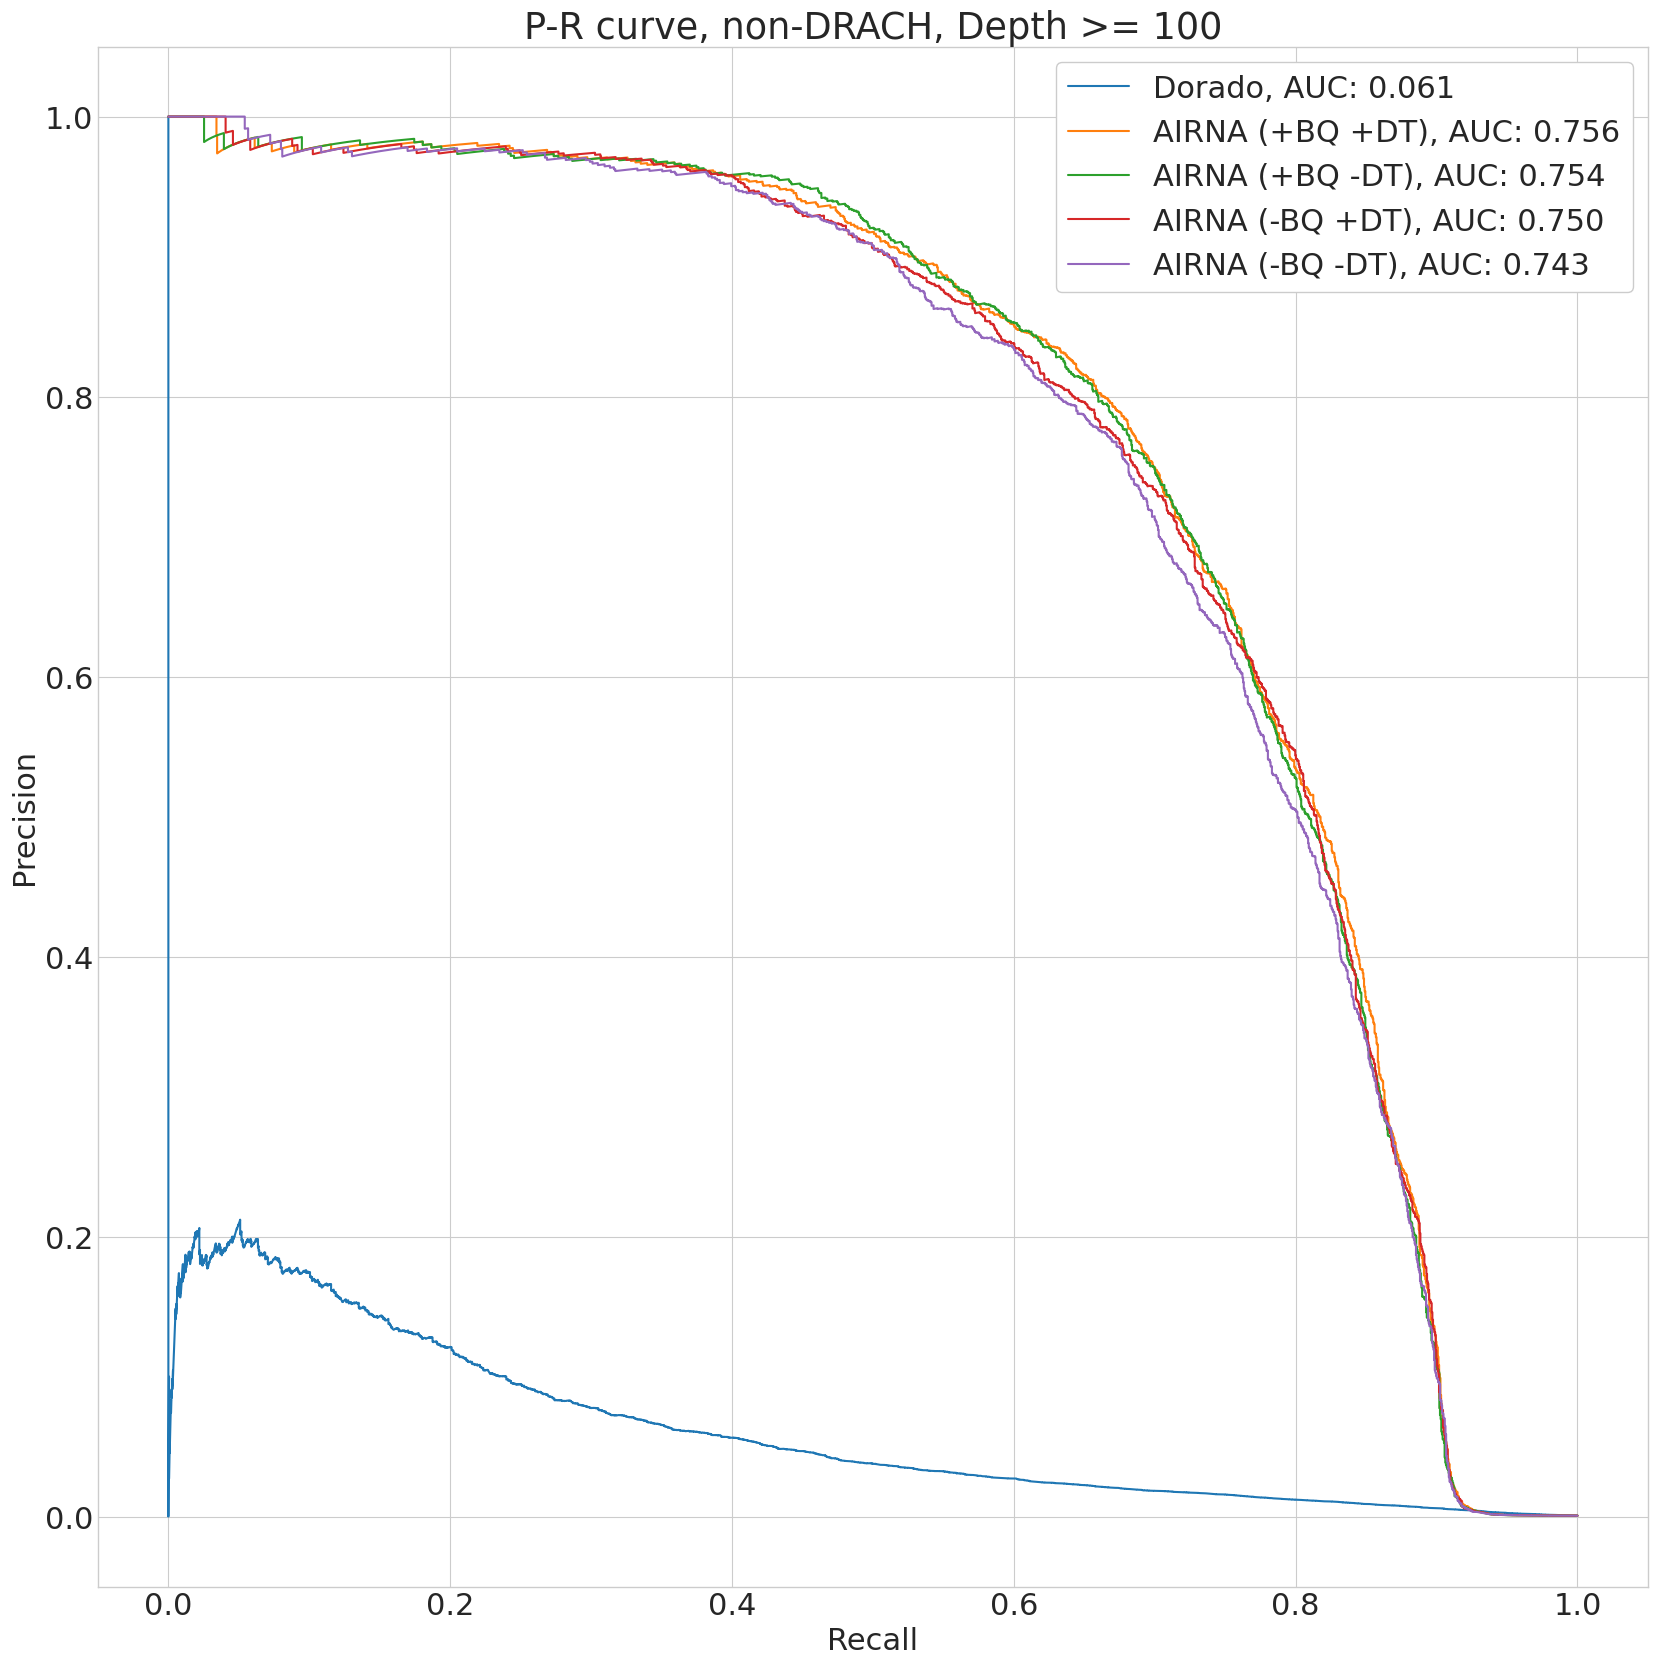

In [81]:
selected_df_bq_dt = eval_df[(~eval_df["drach"]) & (eval_df["count_dom"] >= 100) & (eval_df["label"] >= 0)]
selected_df_bq_dt = selected_df_bq_dt[(selected_df_bq_dt["label"] == 0)|(selected_df_bq_dt["dom_label"] > 0.1)]

selected_df_bq_nodt = bq_nodt_df[(~bq_nodt_df["drach"]) & (bq_nodt_df["count_dom"] >= 100) & (bq_nodt_df["label"] >= 0)]
selected_df_bq_nodt = selected_df_bq_nodt[(selected_df_bq_nodt["label"] == 0)|(selected_df_bq_nodt["dom_label"] > 0.1)]

selected_df_nobq_dt = nobq_dt_df[(~nobq_dt_df["drach"]) & (nobq_dt_df["count_dom"] >= 100) & (nobq_dt_df["label"] >= 0)]
selected_df_nobq_dt = selected_df_nobq_dt[(selected_df_nobq_dt["label"] == 0)|(selected_df_nobq_dt["dom_label"] > 0.1)]

selected_df_nobq_nodt = nobq_nodt_df[(~nobq_nodt_df["drach"]) & (nobq_nodt_df["count_dom"] >= 100) & (nobq_nodt_df["label"] >= 0)]
selected_df_nobq_nodt = selected_df_nobq_nodt[(selected_df_nobq_nodt["label"] == 0)|(selected_df_nobq_nodt["dom_label"] > 0.1)]


plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1})
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

precision, recall, _ = precision_recall_curve(selected_df_bq_dt["label"], selected_df_bq_dt["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df_bq_dt["label"], selected_df_bq_dt["log_pm6a"] + (1-selected_df_bq_dt["dom"])*np.log10(np.clip(1-selected_df_bq_dt["dom"],1e-30,1)))
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (+BQ +DT), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df_bq_nodt["label"], selected_df_bq_nodt["log_pm6a"] + (1-selected_df_bq_nodt["dom"])*np.log10(np.clip(1-selected_df_bq_nodt["dom"],1e-30,1)))
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (+BQ -DT), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df_nobq_dt["label"], selected_df_nobq_dt["log_pm6a"] + (1-selected_df_nobq_dt["dom"])*np.log10(np.clip(1-selected_df_nobq_dt["dom"],1e-30,1)))
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (-BQ +DT), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df_nobq_nodt["label"], selected_df_nobq_nodt["log_pm6a"] + (1-selected_df_nobq_nodt["dom"])*np.log10(np.clip(1-selected_df_nobq_nodt["dom"],1e-30,1)))
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (-BQ -DT), AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve, non-DRACH, Depth >= 100")
ax.legend()
plt.show()


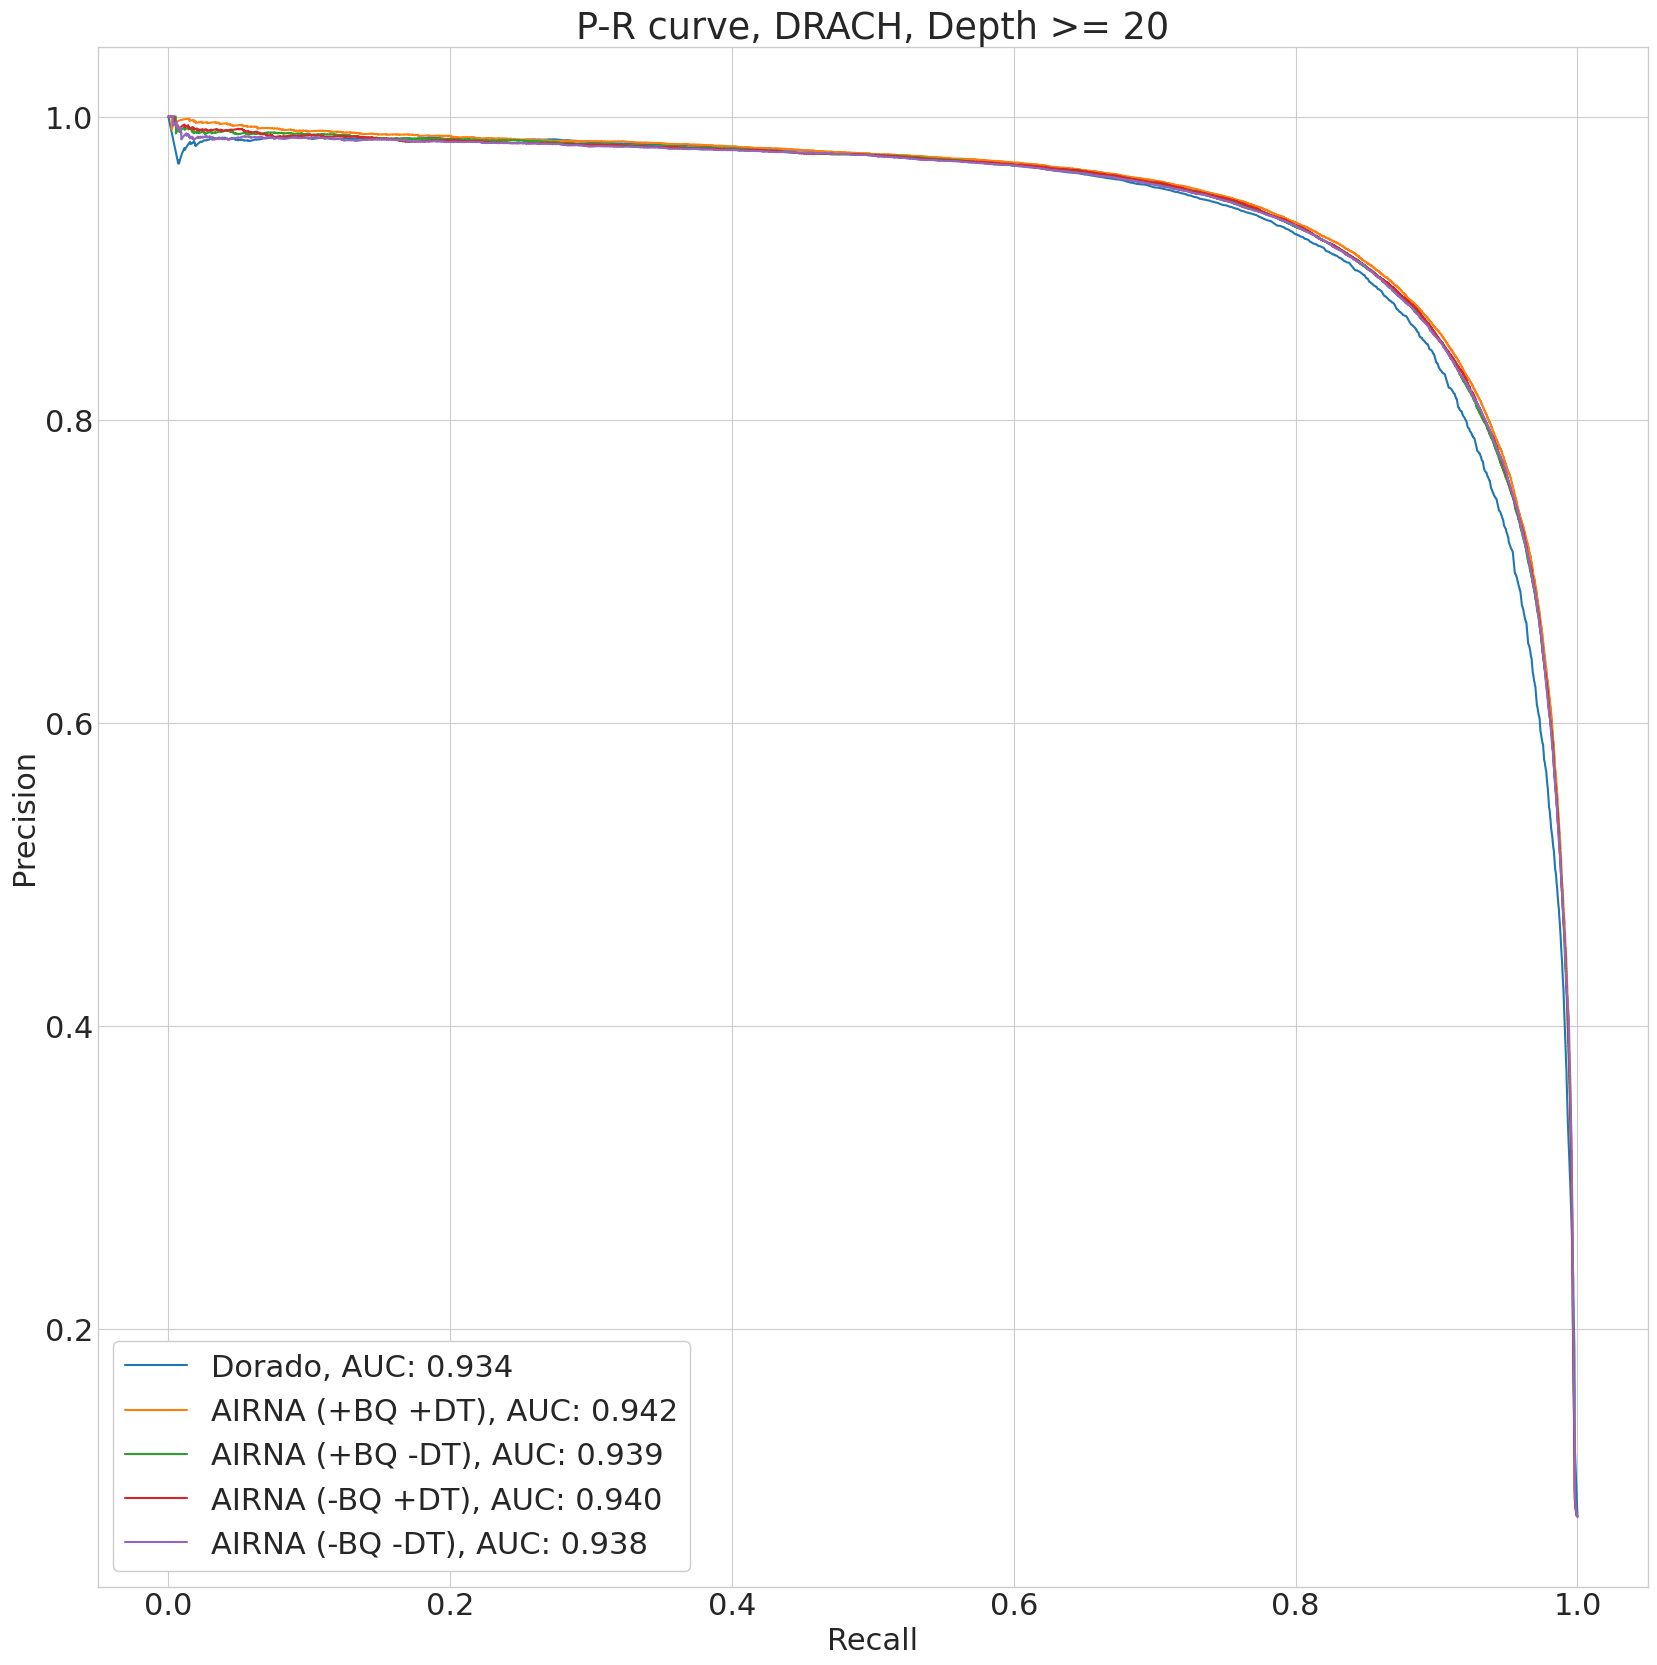

In [78]:
selected_df_bq_dt = eval_df[(eval_df["drach"]) & (eval_df["count_dom"] >= 20) & (eval_df["label"] >= 0)]
selected_df_bq_dt = selected_df_bq_dt[(selected_df_bq_dt["label"] == 0)|(selected_df_bq_dt["dom_label"] > 0.1)]

selected_df_bq_nodt = bq_nodt_df[(bq_nodt_df["drach"]) & (bq_nodt_df["count_dom"] >= 20) & (bq_nodt_df["label"] >= 0)]
selected_df_bq_nodt = selected_df_bq_nodt[(selected_df_bq_nodt["label"] == 0)|(selected_df_bq_nodt["dom_label"] > 0.1)]

selected_df_nobq_dt = nobq_dt_df[(nobq_dt_df["drach"]) & (nobq_dt_df["count_dom"] >= 20) & (nobq_dt_df["label"] >= 0)]
selected_df_nobq_dt = selected_df_nobq_dt[(selected_df_nobq_dt["label"] == 0)|(selected_df_nobq_dt["dom_label"] > 0.1)]
selected_df_nobq_dt["log_pm6a"] = np.clip(selected_df_nobq_dt["log_pm6a"], 0, 1e+30)

selected_df_nobq_nodt = nobq_nodt_df[(nobq_nodt_df["drach"]) & (nobq_nodt_df["count_dom"] >= 20) & (nobq_nodt_df["label"] >= 0)]
selected_df_nobq_nodt = selected_df_nobq_nodt[(selected_df_nobq_nodt["label"] == 0)|(selected_df_nobq_nodt["dom_label"] > 0.1)]

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1})
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

precision, recall, _ = precision_recall_curve(selected_df_bq_dt["label"], selected_df_bq_dt["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df_bq_dt["label"], selected_df_bq_dt["log_pm6a"] + (1-selected_df_bq_dt["dom"])*np.log10(np.clip(1-selected_df_bq_dt["dom"],1e-30,1)))
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (+BQ +DT), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df_bq_nodt["label"], selected_df_bq_nodt["log_pm6a"] + (1-selected_df_bq_nodt["dom"])*np.log10(np.clip(1-selected_df_bq_nodt["dom"],1e-30,1)))
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (+BQ -DT), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df_nobq_dt["label"], selected_df_nobq_dt["log_pm6a"] + (1-selected_df_nobq_dt["dom"])*np.log10(np.clip(1-selected_df_nobq_dt["dom"],1e-30,1)))
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (-BQ +DT), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df_nobq_nodt["label"], selected_df_nobq_nodt["log_pm6a"] + (1-selected_df_nobq_nodt["dom"])*np.log10(np.clip(1-selected_df_nobq_nodt["dom"],1e-30,1)))
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (-BQ -DT), AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve, DRACH, Depth >= 20")
legend = ax.legend()
plt.show()



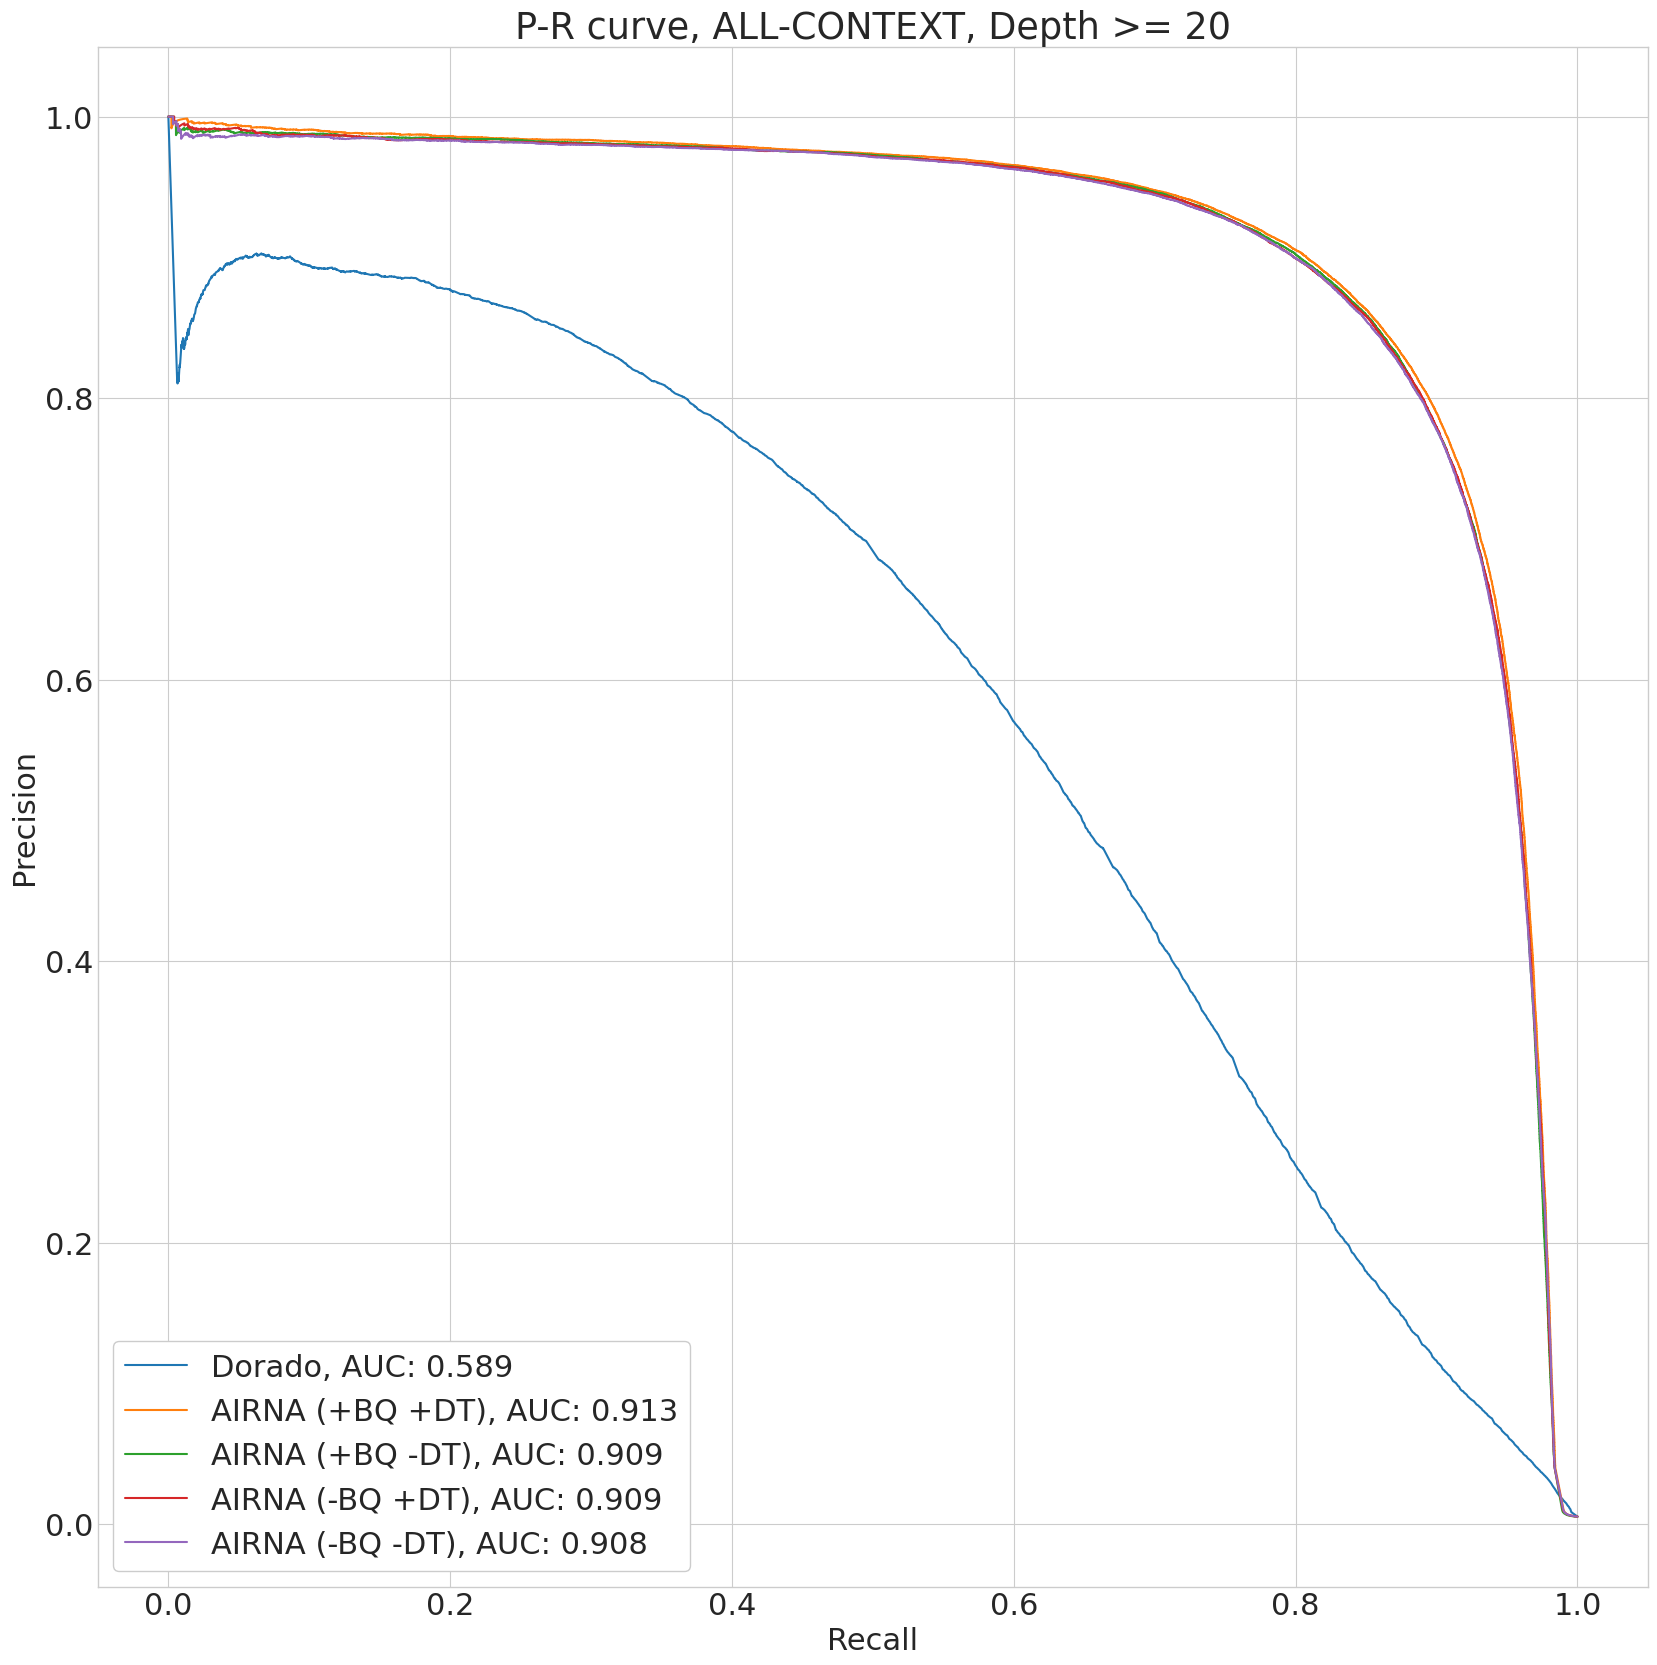

In [80]:
selected_df_bq_dt = eval_df[(eval_df["count_dom"] >= 20) & (eval_df["label"] >= 0)]
selected_df_bq_dt = selected_df_bq_dt[(selected_df_bq_dt["label"] == 0)|(selected_df_bq_dt["dom_label"] > 0.1)]

selected_df_bq_nodt = bq_nodt_df[(bq_nodt_df["count_dom"] >= 20) & (bq_nodt_df["label"] >= 0)]
selected_df_bq_nodt = selected_df_bq_nodt[(selected_df_bq_nodt["label"] == 0)|(selected_df_bq_nodt["dom_label"] > 0.1)]

selected_df_nobq_dt = nobq_dt_df[(nobq_dt_df["count_dom"] >= 20) & (nobq_dt_df["label"] >= 0)]
selected_df_nobq_dt = selected_df_nobq_dt[(selected_df_nobq_dt["label"] == 0)|(selected_df_nobq_dt["dom_label"] > 0.1)]
selected_df_nobq_dt["log_pm6a"] = np.clip(selected_df_nobq_dt["log_pm6a"], 0, 1e+30)

selected_df_nobq_nodt = nobq_nodt_df[(nobq_nodt_df["count_dom"] >= 20) & (nobq_nodt_df["label"] >= 0)]
selected_df_nobq_nodt = selected_df_nobq_nodt[(selected_df_nobq_nodt["label"] == 0)|(selected_df_nobq_nodt["dom_label"] > 0.1)]


plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1})
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

precision, recall, _ = precision_recall_curve(selected_df_bq_dt["label"], selected_df_bq_dt["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df_bq_dt["label"], selected_df_bq_dt["log_pm6a"] + (1-selected_df_bq_dt["dom"])*np.log10(np.clip(1-selected_df_bq_dt["dom"],1e-30,1)))
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (+BQ +DT), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df_bq_nodt["label"], selected_df_bq_nodt["log_pm6a"] + (1-selected_df_bq_nodt["dom"])*np.log10(np.clip(1-selected_df_bq_nodt["dom"],1e-30,1)))
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (+BQ -DT), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df_nobq_dt["label"], selected_df_nobq_dt["log_pm6a"] + (1-selected_df_nobq_dt["dom"])*np.log10(np.clip(1-selected_df_nobq_dt["dom"],1e-30,1)))
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (-BQ +DT), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df_nobq_nodt["label"], selected_df_nobq_nodt["log_pm6a"] + (1-selected_df_nobq_nodt["dom"])*np.log10(np.clip(1-selected_df_nobq_nodt["dom"],1e-30,1)))
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (-BQ -DT), AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve, ALL-CONTEXT, Depth >= 20")
ax.legend()
plt.show()



In [39]:
logsum_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_psum/pileup.npz"
with np.load(logsum_df, allow_pickle=True) as data:
    logsum_df = pd.DataFrame({key: data[key] for key in data.keys()})
logsum_df = logsum_df[logsum_df["count_dom"] >= 20]
logsum_df = logsum_df.merge(label_df_filtered, on="label_id", how="inner")
print(logsum_df)

                label_id     p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
0         NM_000016:1000  0.606511      0.000000        0.000000          0   
1         NM_000016:1008  0.948786      0.000000        0.000000          0   
2         NM_000016:1009  2.607620      0.000000        0.000000          0   
3         NM_000016:1010  4.912612      0.000000        0.000000          0   
4         NM_000016:1014  3.237954      0.000000        0.000000          0   
...                  ...       ...           ...             ...        ...   
10794116  NR_182669:3964  1.226287      0.000000        0.000000          0   
10794117  NR_182669:3965  1.268912      0.000000        0.000000          0   
10794118  NR_182669:3966  1.295230      0.000000        0.000000          0   
10794119  NR_182669:3968  2.394934     -0.006871       -1.804221          1   
10794120  NR_182669:3969  1.723521      0.000000        0.000000          0   

          logsum_p_neg  logsum_1_p_neg  count_neg  

In [40]:
logsum_df = logsum_df.merge(dorado_df, on="label_id", how="inner")
print(logsum_df)

                label_id     p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
0         NM_000016:1000  0.606511      0.000000        0.000000          0   
1         NM_000016:1008  0.948786      0.000000        0.000000          0   
2         NM_000016:1009  2.607620      0.000000        0.000000          0   
3         NM_000016:1010  4.912612      0.000000        0.000000          0   
4         NM_000016:1014  3.237954      0.000000        0.000000          0   
...                  ...       ...           ...             ...        ...   
10340557  NR_182669:3964  1.226287      0.000000        0.000000          0   
10340558  NR_182669:3965  1.268912      0.000000        0.000000          0   
10340559  NR_182669:3966  1.295230      0.000000        0.000000          0   
10340560  NR_182669:3968  2.394934     -0.006871       -1.804221          1   
10340561  NR_182669:3969  1.723521      0.000000        0.000000          0   

          logsum_p_neg  logsum_1_p_neg  count_neg  

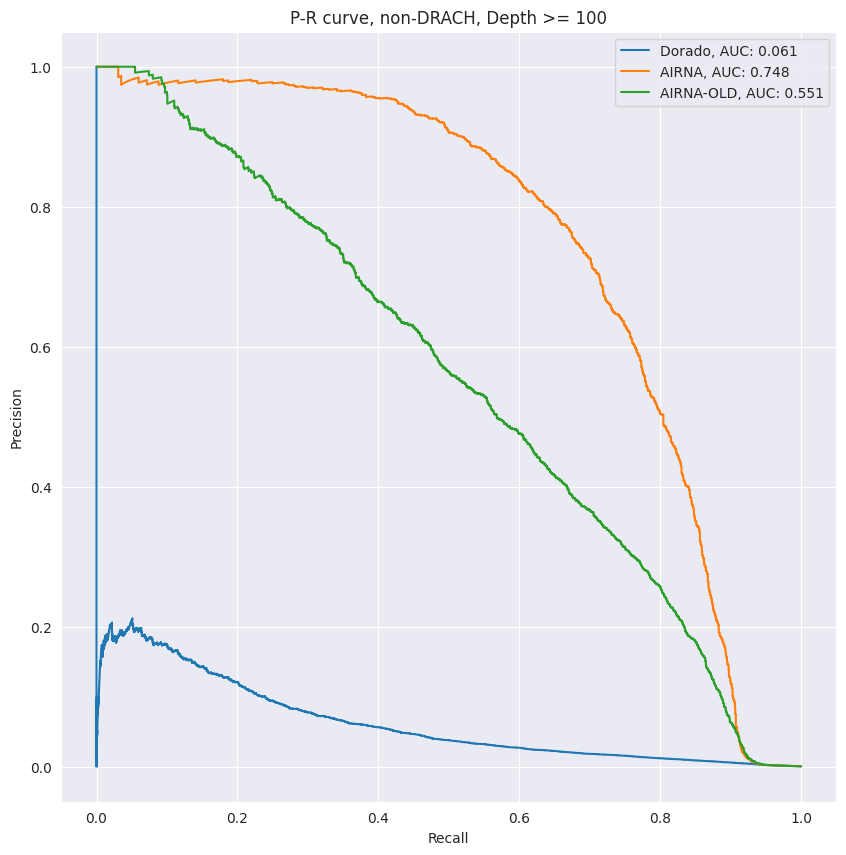

In [43]:
selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]


selected_df["log_pm6a"] =  -(2-selected_df["dom"])*selected_df["logsum_1_p_pos"]/selected_df["count_all"]
selected_df["old_pm6a"] =  1-10**((selected_df["logsum_1_p_pos"]+selected_df["logsum_1_p_neg"])/(selected_df["count_pos"]+selected_df["count_neg"]))
selected_df["threshold"] = 1-((0.9 ** (1-data_df_selected["dom"])) * (0.02 ** (data_df_selected["dom_070"])))


fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["old_pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA-OLD, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["log_pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve, non-DRACH, Depth >= 100")
ax.legend()
plt.show()


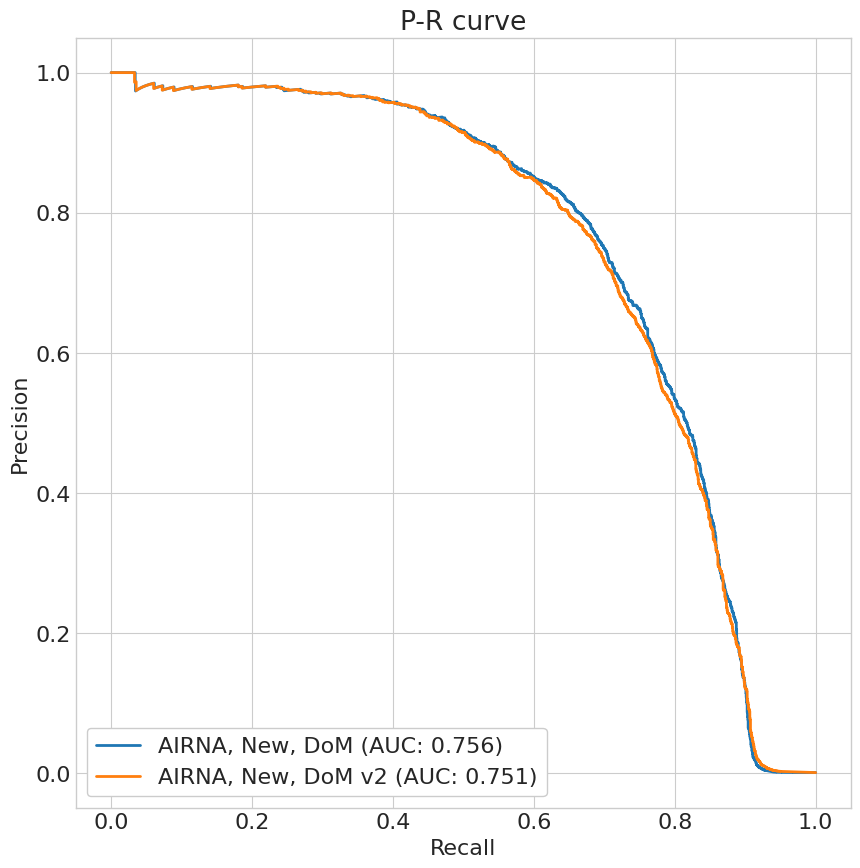

In [102]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]

selected_df["pm6a_neg"] =  1-10**((selected_df["logsum_1_p_pos"]+selected_df["logsum_1_p_neg"])/(selected_df["count_pos"]+selected_df["count_neg"]))
selected_df["threshold"] = 1-((0.9 ** (1-selected_df["dom"])) * (0.02 ** (selected_df["dom"])))
selected_df["pm6a_neg_thr"] = selected_df["pm6a_neg"] * (selected_df["pm6a_neg"] > selected_df["threshold"])
selected_df["pm6a_pos"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["pm6a_pos_dom"] =  -(2-selected_df["dom"])*selected_df["logsum_1_p_pos"]/selected_df["count_all"] + (1-selected_df["dom"])*np.log10(np.clip(1-selected_df["dom"],1e-30,1))
selected_df["pm6a_pos_dom_v2"] =  -(2-selected_df["dom"])*selected_df["logsum_1_p_pos"]/selected_df["count_all"] + ((1-selected_df["dom"])*np.log10(np.clip(1-selected_df["dom"],1e-30,1)) + selected_df["dom"] * np.log10(np.clip(selected_df["dom"],1e-30,1)))*(selected_df["count_pos"]/selected_df["count_all"])

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 16, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_pos_dom"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, New, DoM (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_pos_dom_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, New, DoM v2 (AUC: {auc_score:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend(loc="lower left")
plt.show()


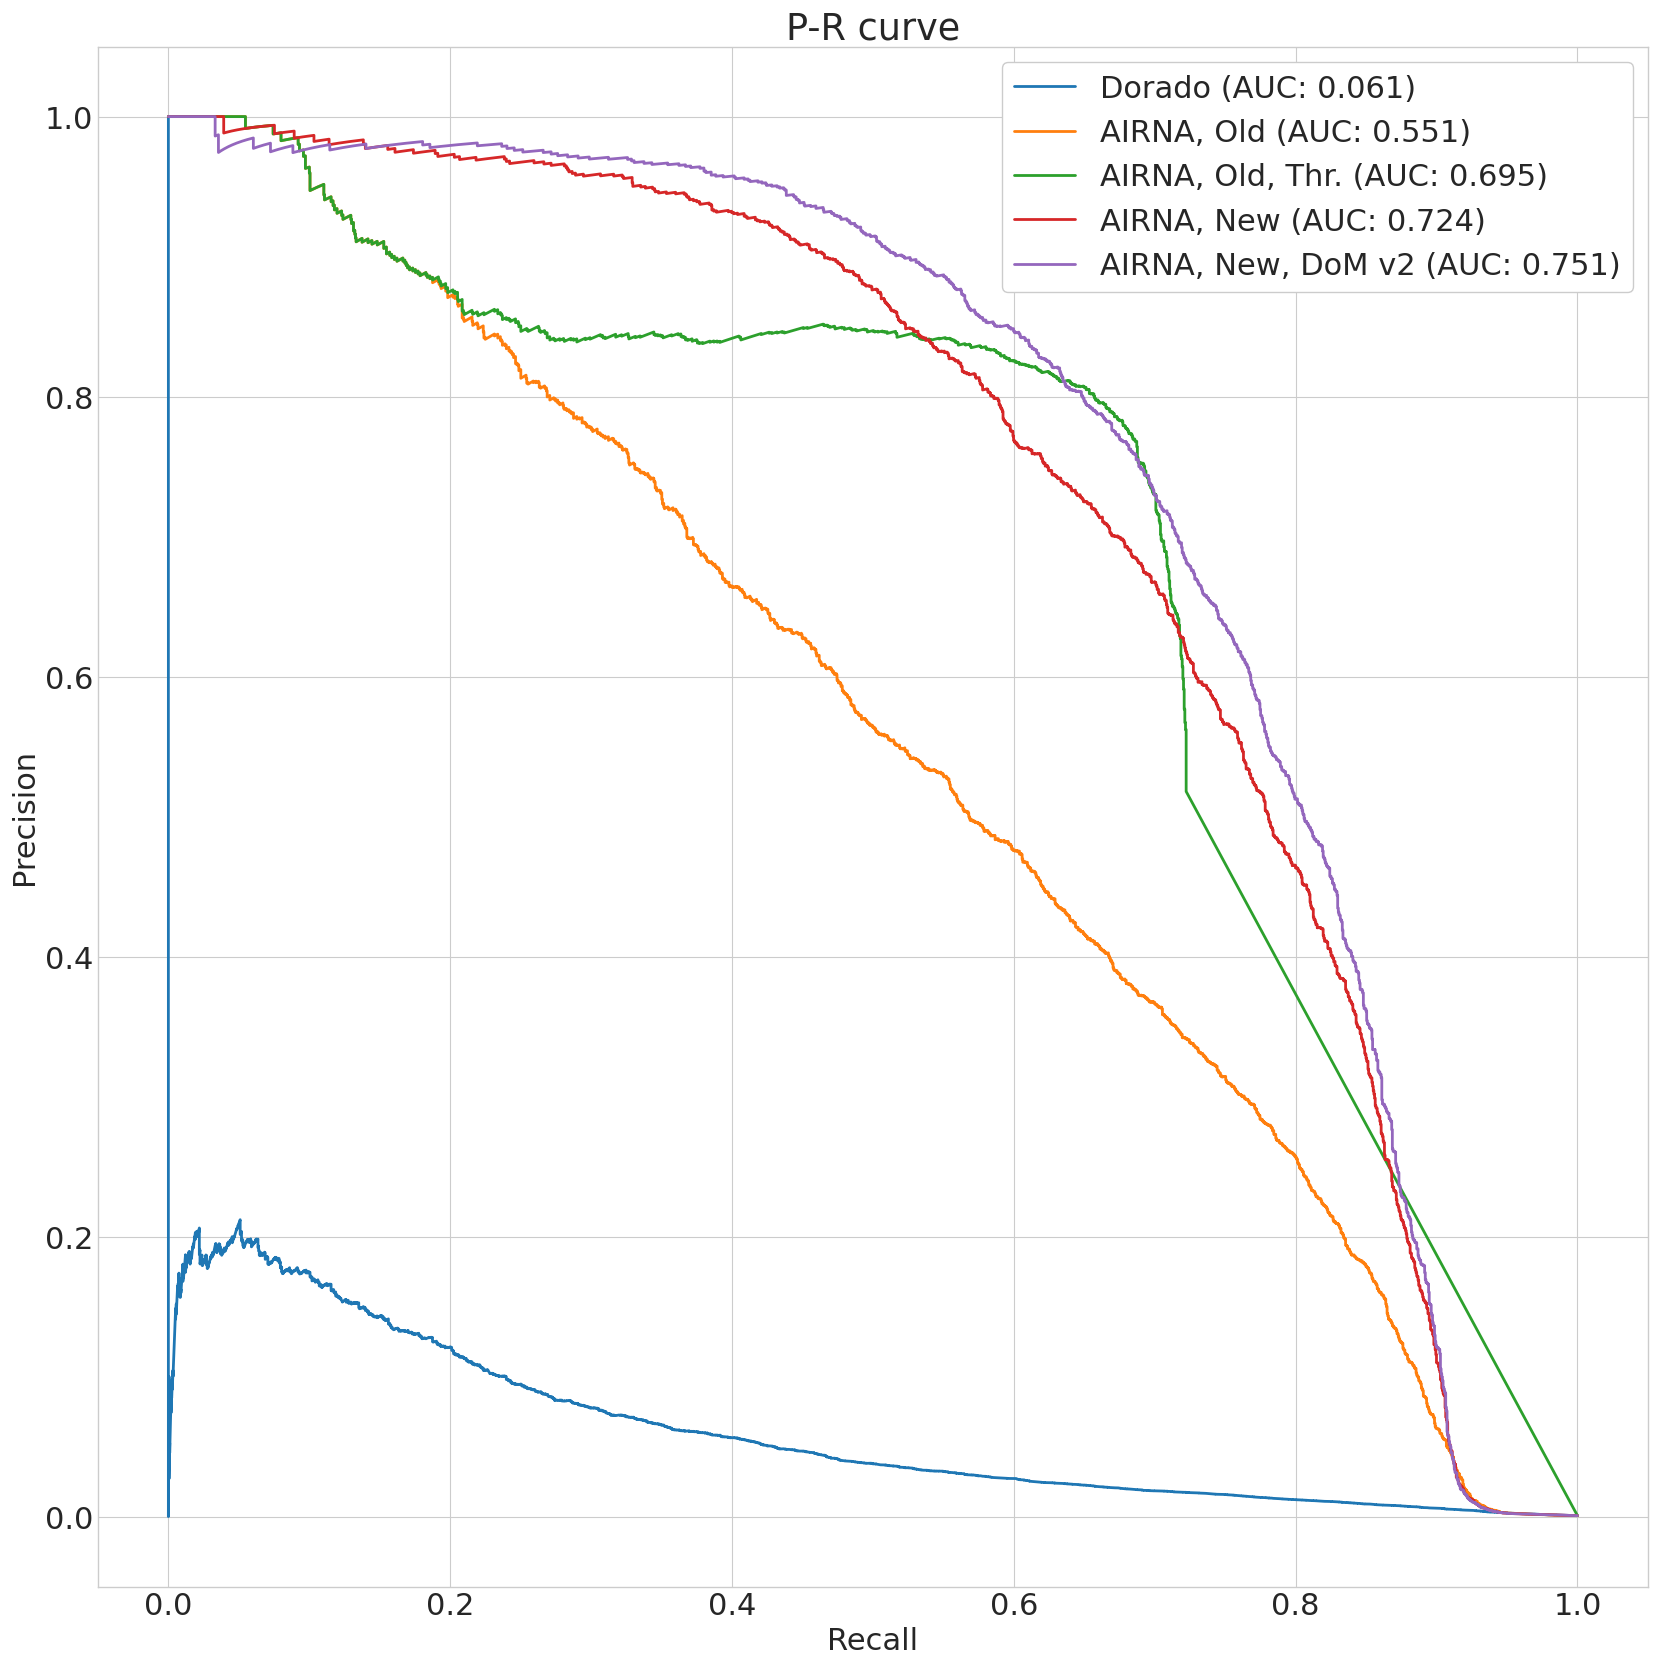

In [101]:
fpr = 0.0027

selected_df = logsum_df[(~logsum_df["drach"]) & (logsum_df["count_dom"] >= 100) & (logsum_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]

selected_df["pm6a_neg"] =  1-10**((selected_df["logsum_1_p_pos"]+selected_df["logsum_1_p_neg"])/(selected_df["count_pos"]+selected_df["count_neg"]))
selected_df["threshold"] = 1-((0.9 ** (1-selected_df["dom"])) * (0.02 ** (selected_df["dom"])))
selected_df["pm6a_neg_thr"] = selected_df["pm6a_neg"] * (selected_df["pm6a_neg"] > selected_df["threshold"])
selected_df["pm6a_pos"] = -(selected_df["logsum_1_p_pos"]/np.clip(selected_df["count_all"],1,None))
selected_df["p_avg"] = selected_df["p_sum"] / selected_df["count_all"]
selected_df["pm6a_pos_dom_v2"] =  -(2-selected_df["dom"])*selected_df["logsum_1_p_pos"]/selected_df["count_all"] + ((1-selected_df["dom"])*np.log10(np.clip(1-selected_df["dom"],1e-30,1)) + selected_df["dom"] * np.log10(np.clip(selected_df["dom"],1e-30,1)))*(selected_df["count_pos"]/selected_df["count_all"])

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_neg"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, Old (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_neg_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, Old, Thr. (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_pos"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, New (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_pos_dom_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA, New, DoM v2 (AUC: {auc_score:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend(loc="upper right")
plt.show()


In [96]:
df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif/inference_1_3000.pkl")
print(df["pred"].describe())

count    1000000.000000
mean           0.044691
std            0.150249
min            0.000009
25%            0.000322
50%            0.000840
75%            0.005720
max            0.999994
Name: pred, dtype: float64


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


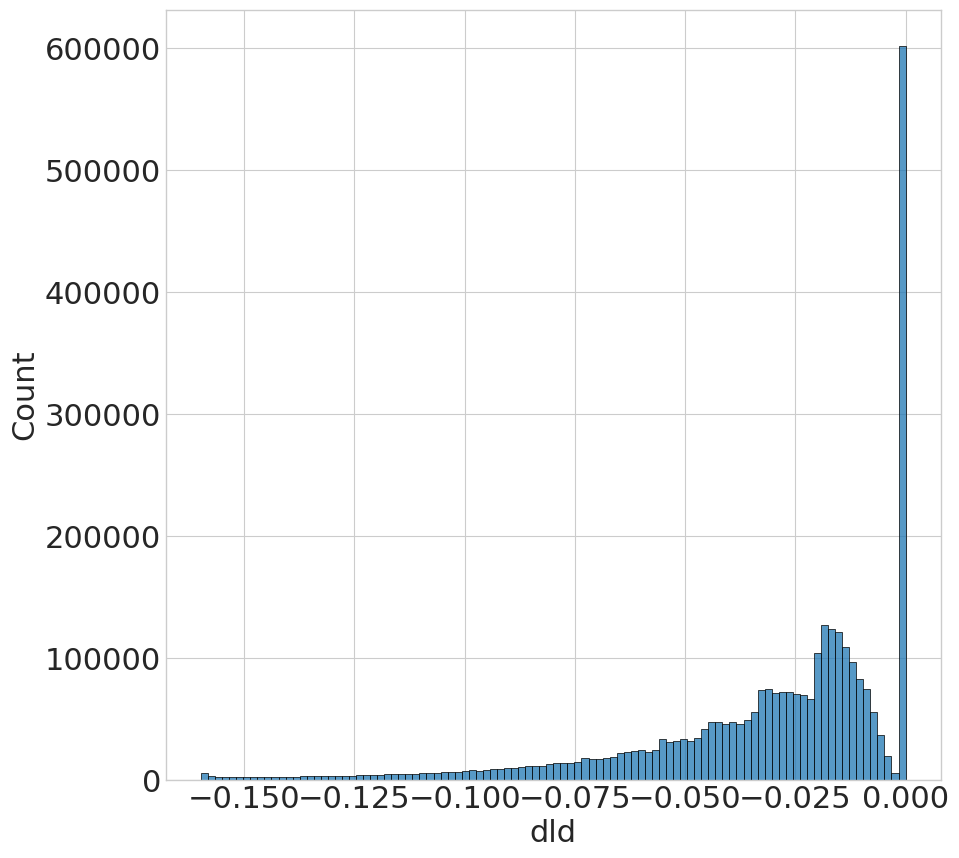

In [97]:
selected_df["dld"] = selected_df["dom"] * np.log10(np.clip(selected_df["dom"],1e-30,1))

## histogram
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
sns.histplot(selected_df["dld"], bins=100, ax=ax)
plt.show()

In [105]:
dorado_080_df_original = "/extdata4/baeklab/Hyeonseo/m6A/dorado-080/ON0090_dorado_basecall.bed"
mod = "a"

dorado_080_df_original = pd.read_csv(dorado_080_df_original, quoting = 3, sep = "\t", header = None, dtype=str)
## Keep column 0, 1, 4, 9

In [106]:
dorado_080_df = dorado_080_df_original[[0, 1, 3, 4, 9]].copy()
dorado_080_df.columns = ["nmid", "pos", "mod", "depth", "pred_dorado"]
dorado_080_df = dorado_080_df[dorado_080_df["mod"] == mod].copy()
dorado_080_df["depth"] = dorado_080_df["depth"].astype(int)
dorado_080_df["dom"] = dorado_080_df["pred_dorado"].str.split(" ").str[1].astype(float) / 100
dorado_080_df["label_id"] = dorado_080_df["nmid"].str.split(".").str[0] + ":" + dorado_080_df["pos"]
dorado_080_df = dorado_080_df[["label_id", "dom", "depth"]].copy()
dorado_080_df.rename(columns = {"depth": "count_dom"}, inplace = True)
print(dorado_080_df)

                 label_id  dom  count_dom
0             NM_000015:0  0.0          1
5             NM_000015:5  0.0          2
9             NM_000015:8  0.5          2
12           NM_000015:10  0.0          1
14           NM_000015:12  0.0          1
...                   ...  ...        ...
231107875  NR_184563:6992  0.0          1
231107879  NR_184563:6999  0.0          1
231107881  NR_184563:7000  1.0          1
231107884  NR_184563:7002  0.0          1
231107888  NR_184563:7005  0.0          1

[59327555 rows x 3 columns]


In [109]:
dorado_080_df.reset_index(inplace=True, drop=True)

dorado_080_df.to_pickle("/extdata4/baeklab/Hyeonseo/m6A/dorado-080/ON0090_dorado_basecall.bed" + ".m6A.pkl")
print(dorado_080_df)

                label_id  dom  count_dom
0            NM_000015:0  0.0          1
1            NM_000015:5  0.0          2
2            NM_000015:8  0.5          2
3           NM_000015:10  0.0          1
4           NM_000015:12  0.0          1
...                  ...  ...        ...
59327550  NR_184563:6992  0.0          1
59327551  NR_184563:6999  0.0          1
59327552  NR_184563:7000  1.0          1
59327553  NR_184563:7002  0.0          1
59327554  NR_184563:7005  0.0          1

[59327555 rows x 3 columns]


In [111]:
dorado_080_df.rename(columns = {"count_dom": "dorado_count", "dom": "pred_dorado"}, inplace = True)
dorado_080_df = dorado_080_df[dorado_080_df["dorado_count"] >= 20]
dorado_080_df = dorado_080_df.merge(label_df_filtered, on="label_id", how="inner")
dorado_080_df = dorado_080_df[["pred_dorado", "dorado_count", "label_id"]]
print(dorado_080_df)    

          pred_dorado  dorado_count        label_id
0              0.0125           160    NM_000016:21
1              0.0616           146    NM_000016:24
2              0.0412           170    NM_000016:29
3              0.0167           180    NM_000016:30
4              0.0000           181    NM_000016:38
...               ...           ...             ...
10398226       0.0492            61  NR_182669:3965
10398227       0.2593            54  NR_182669:3966
10398228       0.0000            60  NR_182669:3968
10398229       0.0000            59  NR_182669:3969
10398230       0.0323            31  NR_182669:3979

[10398231 rows x 3 columns]


In [114]:
print(logsum_df)
dorado_080_df.rename(columns = {"dorado_count": "dorado_count_080", "pred_dorado": "pred_dorado_080"}, inplace = True)
eval_df = logsum_df.merge(dorado_df, on="label_id", how="inner")
eval_df = eval_df.merge(dorado_080_df, on="label_id", how="inner")
print(eval_df)

                label_id     p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
0         NM_000016:1000  0.606511      0.000000        0.000000          0   
1         NM_000016:1008  0.948786      0.000000        0.000000          0   
2         NM_000016:1009  2.607620      0.000000        0.000000          0   
3         NM_000016:1010  4.912612      0.000000        0.000000          0   
4         NM_000016:1014  3.237954      0.000000        0.000000          0   
...                  ...       ...           ...             ...        ...   
10340557  NR_182669:3964  1.226287      0.000000        0.000000          0   
10340558  NR_182669:3965  1.268912      0.000000        0.000000          0   
10340559  NR_182669:3966  1.295230      0.000000        0.000000          0   
10340560  NR_182669:3968  2.394934     -0.006871       -1.804221          1   
10340561  NR_182669:3969  1.723521      0.000000        0.000000          0   

          logsum_p_neg  logsum_1_p_neg  count_neg  

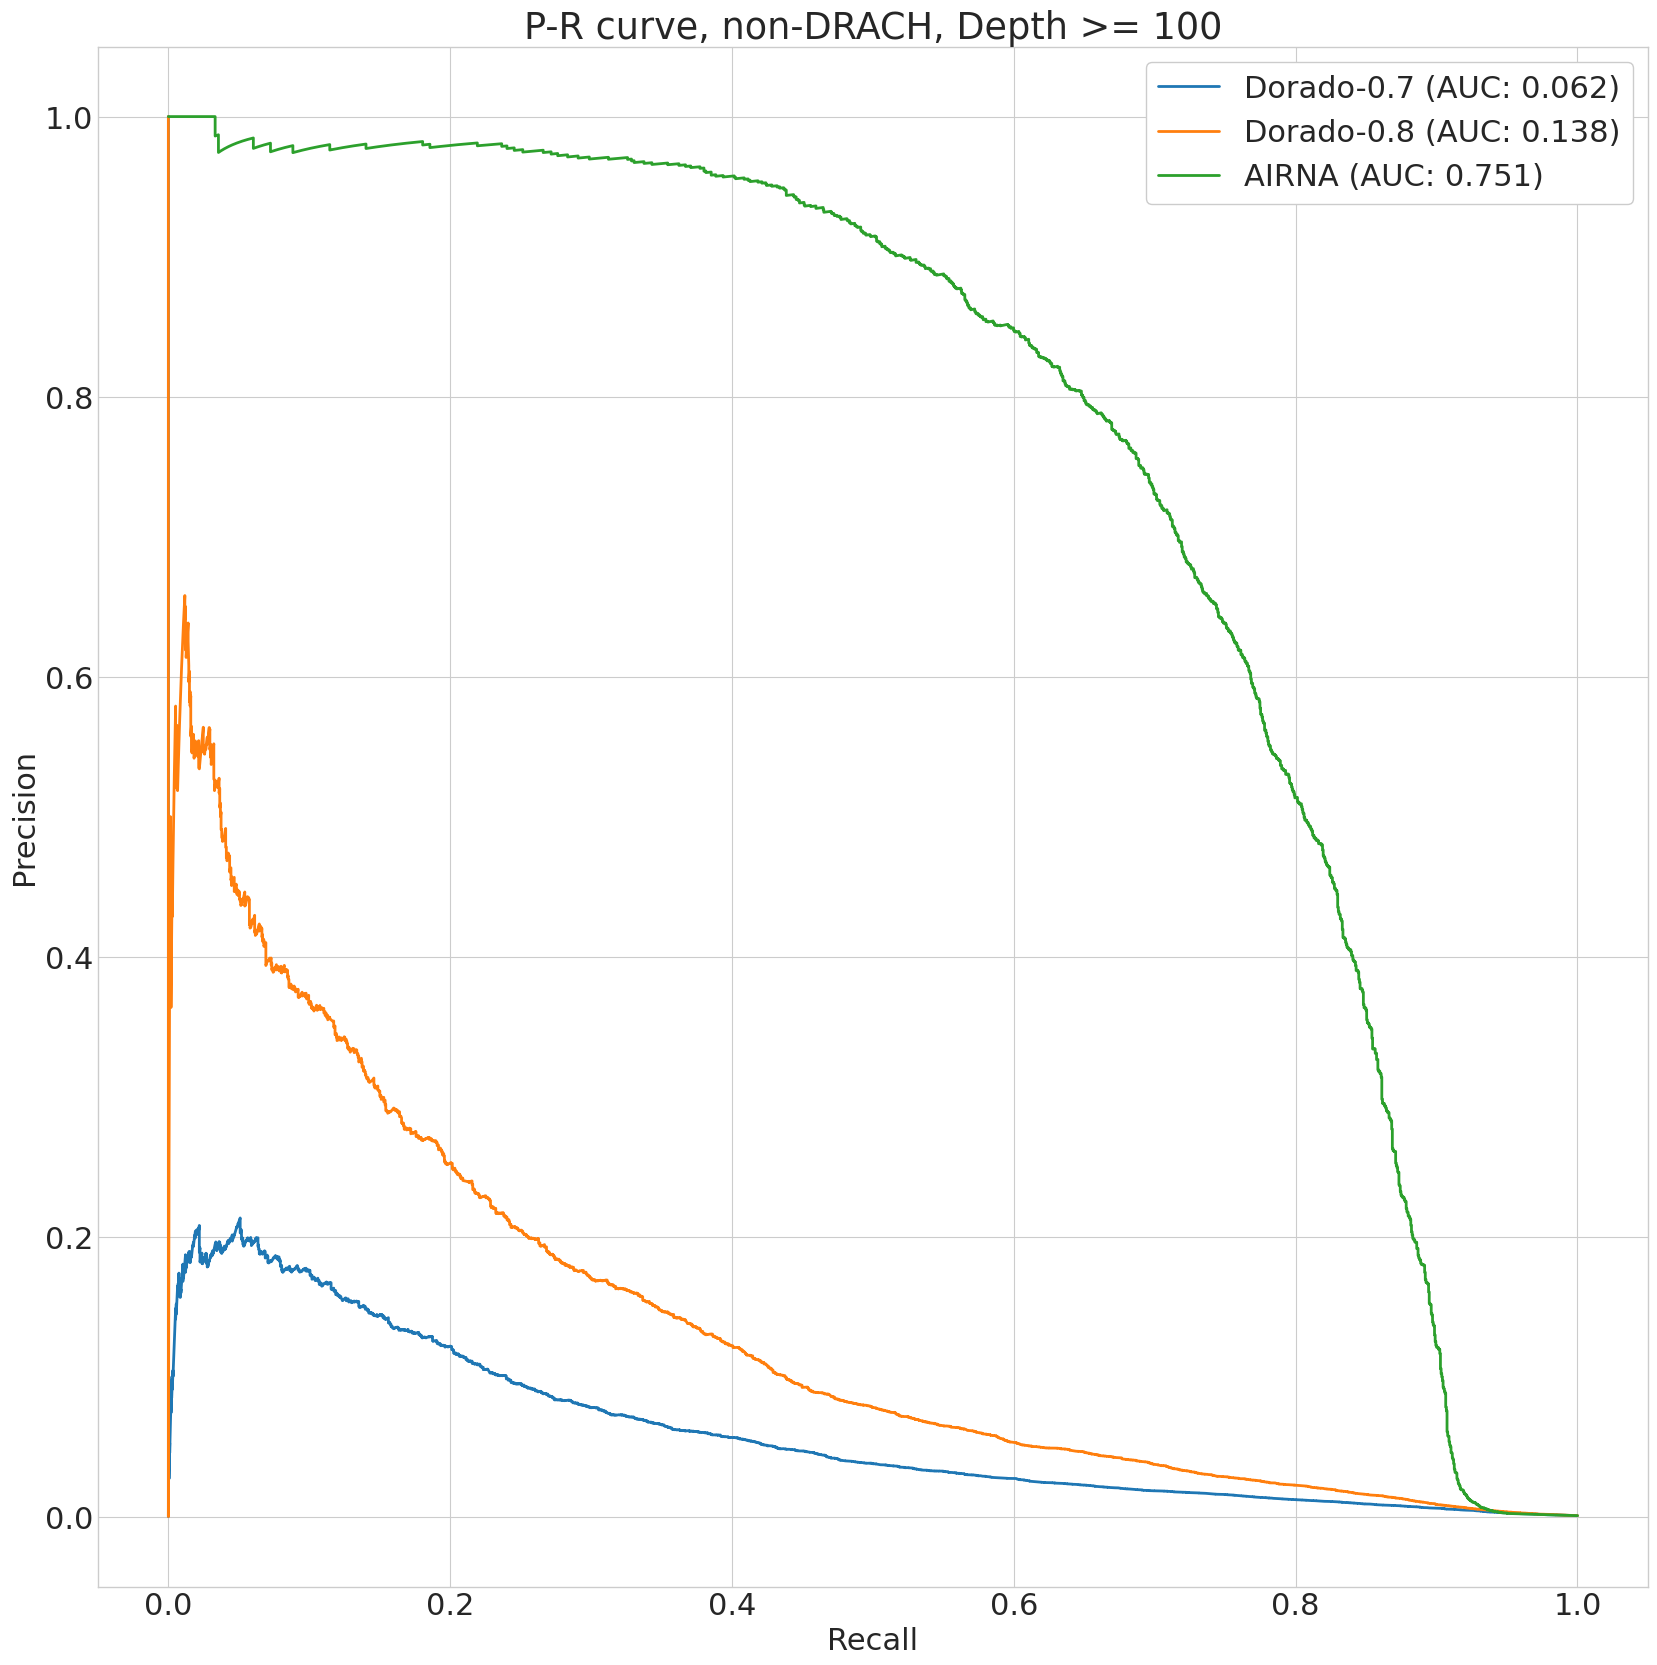

In [119]:
fpr = 0.0027

selected_df = eval_df[(~eval_df["drach"]) & (eval_df["count_dom"] >= 100) & (eval_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]

selected_df["pm6a"] =  -(2-selected_df["dom"])*selected_df["logsum_1_p_pos"]/selected_df["count_all"] + ((1-selected_df["dom"])*np.log10(np.clip(1-selected_df["dom"],1e-30,1)) + selected_df["dom"] * np.log10(np.clip(selected_df["dom"],1e-30,1)))*(selected_df["count_pos"]/selected_df["count_all"])

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado_y"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado-0.7 (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado_080"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado-0.8 (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve, non-DRACH, Depth >= 100")
ax.legend(loc="upper right")
plt.show()


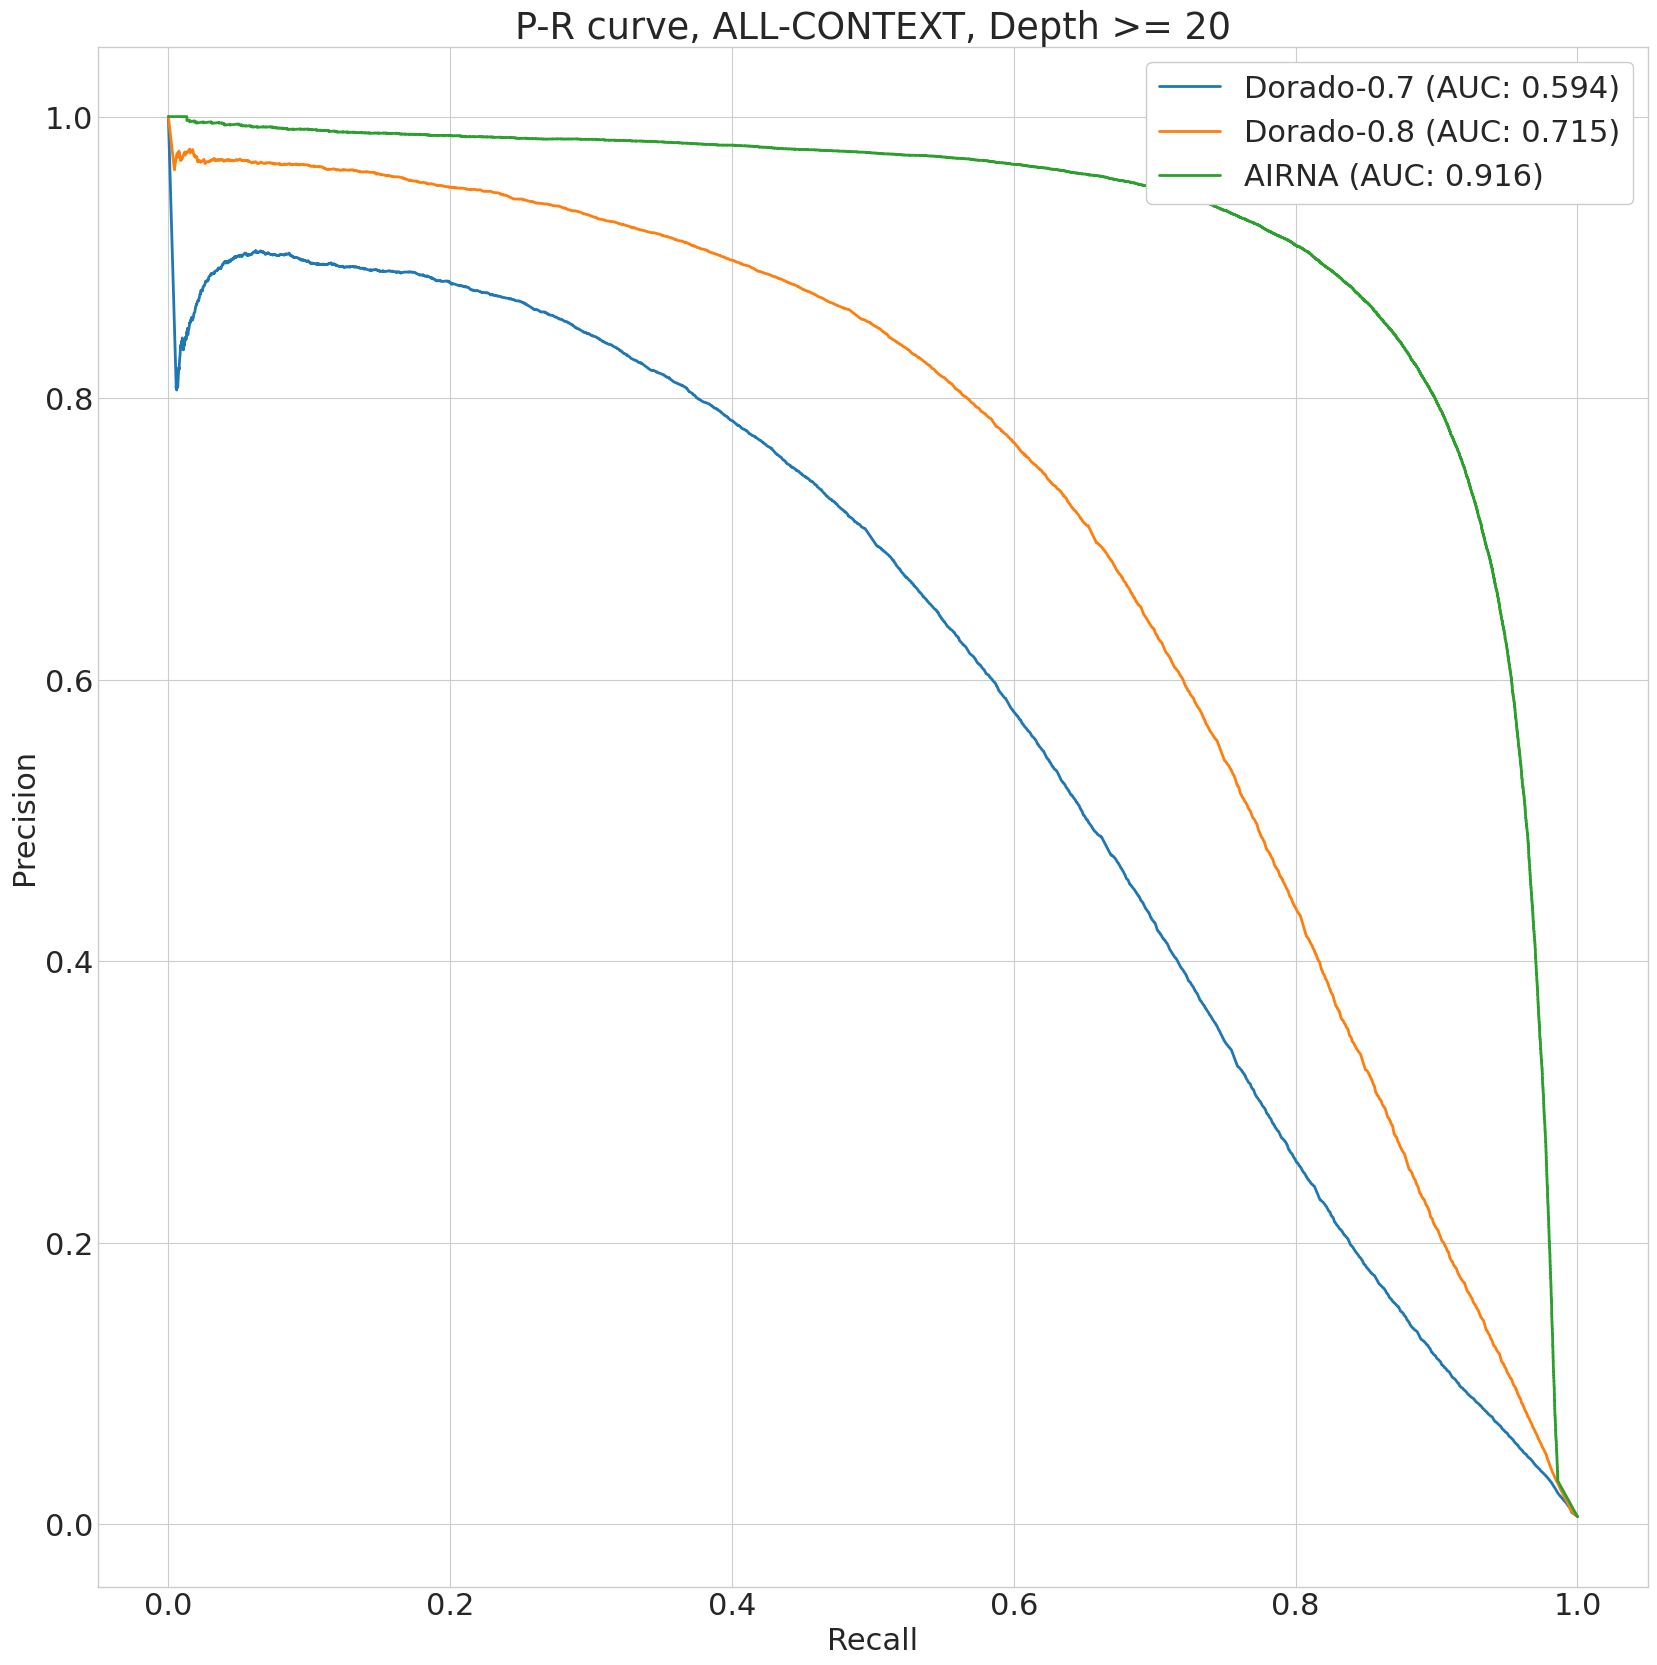

In [120]:
fpr = 0.0027

selected_df = eval_df[(eval_df["count_dom"] >= 20) & (eval_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]

selected_df["pm6a"] =  -(2-selected_df["dom"])*selected_df["logsum_1_p_pos"]/selected_df["count_all"] + ((1-selected_df["dom"])*np.log10(np.clip(1-selected_df["dom"],1e-30,1)) + selected_df["dom"] * np.log10(np.clip(selected_df["dom"],1e-30,1)))*(selected_df["count_pos"]/selected_df["count_all"])

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado_y"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado-0.7 (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado_080"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado-0.8 (AUC: {auc_score:.3f})")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve, ALL-CONTEXT, Depth >= 20")
ax.legend(loc="upper right")
plt.show()


In [122]:
def load_npz(path_list):
    return_dict = {}
    for path in tqdm.tqdm(path_list):
        with np.load(path, allow_pickle=True) as data:
            for key in data.keys():
                if key not in return_dict:
                    return_dict[key] = []
                return_dict[key].append(data[key])
    return_dict = {key: np.concatenate(return_dict[key], axis=0) for key in return_dict.keys()}
    return return_dict
        

In [123]:


pos_data = load_npz(glob.glob("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/block_070/token_normalise_nondrach_poslabel/*.npz"))

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 715/715 [05:14<00:00,  2.27it/s]


In [124]:
import time
time.sleep(600)
neg_data = load_npz(glob.glob("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/block_070/token_normalise_nondrach_neglabel/*.npz"))

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 239/239 [00:59<00:00,  4.01it/s]


In [125]:
print(pos_data.keys())

dict_keys(['segment_len_arr', 'signal_token', 'kmer_token', 'dwell_motor_token', 'dwell_pore_token', 'bq_token', 'label_id'])


In [126]:
print(pos_data["label_id"])

[16709074 21069240 17073829 ...  5704639  1044412  1044414]


In [127]:
pos_data["label_id_str"] = [label_df["label_id"].loc[x] for x in pos_data["label_id"]]
neg_data["label_id_str"] = [label_df["label_id"].loc[x] for x in neg_data["label_id"]]

In [129]:
pos_data["label_id_str"] = np.array(pos_data["label_id_str"])
neg_data["label_id_str"] = np.array(neg_data["label_id_str"])

In [130]:
print(pos_data["label_id_str"])

['NM_016185:434' 'NM_005431:1954' 'NM_001174097:948' ...
 'NM_001018136:908' 'NM_001022:284' 'NM_001022:287']
